# 4. Healthcare Application: ECG Signal Denoising
In this notebook, we demonstrate how our scratch-built algorithms can clean a real-world Electrocardiogram (ECG) signal corrupted by common physiological and environmental noises.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from scipy.datasets import electrocardiogram
except ImportError:
    from scipy.misc import electrocardiogram
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.noise_generation import *
from src.filters import *

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

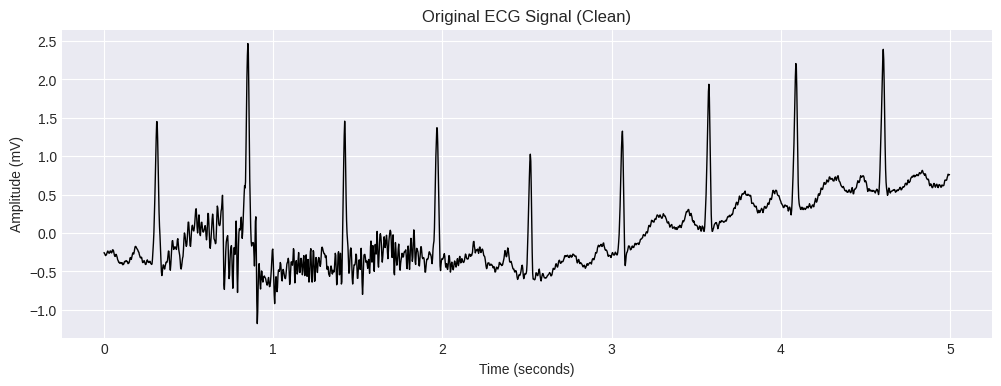

In [2]:


ecg_full = electrocardiogram()
fs = 360  
t = np.arange(1800) / fs
clean_ecg = ecg_full[10000:11800] 

plt.figure(figsize=(12, 4))
plt.plot(t, clean_ecg, color='black', linewidth=1)
plt.title('Original ECG Signal (Clean)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.show()

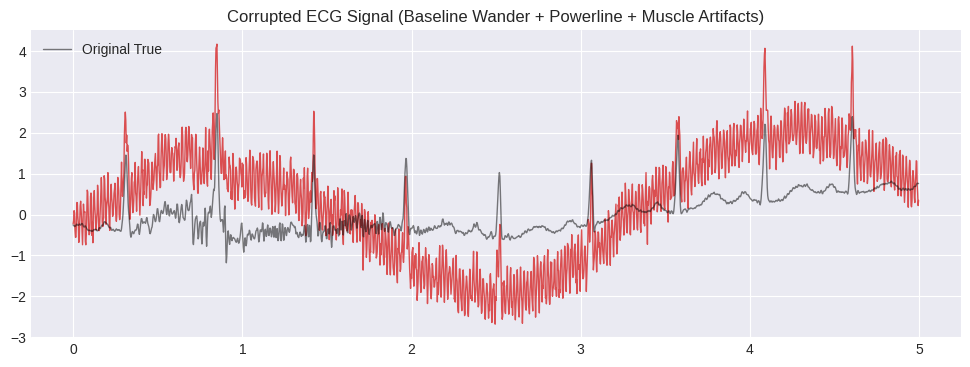

In [ ]:

noisy_ecg = clean_ecg.copy()


baseline_wander = 1.5 * np.sin(2 * np.pi * 0.3 * t)  
noisy_ecg += baseline_wander


powerline_noise = 0.5 * np.sin(2 * np.pi * 50.0 * t)
noisy_ecg += powerline_noise


noisy_ecg = add_gaussian_noise(noisy_ecg, std=0.15)

plt.figure(figsize=(12, 4))
plt.plot(t, noisy_ecg, color='tab:red', linewidth=1, alpha=0.8)
plt.plot(t, clean_ecg, color='black', linewidth=1, label='Original True', alpha=0.5)
plt.title('Corrupted ECG Signal (Baseline Wander + Powerline + Muscle Artifacts)')
plt.legend()
plt.show()

### Applying the Pipeline to Restore the ECG
1. **Baseline Wander Removal**: We use our `moving_average` filter with a wide window to estimate the low-frequency drift, then subtract it. (This acts as a High-Pass filter).
2. **High-Frequency Noise Removal**: We use our `fourier_low_pass_filter` to eliminate frequencies above 40 Hz, cutting out the 50 Hz powerline buzz and muscle artifacts.

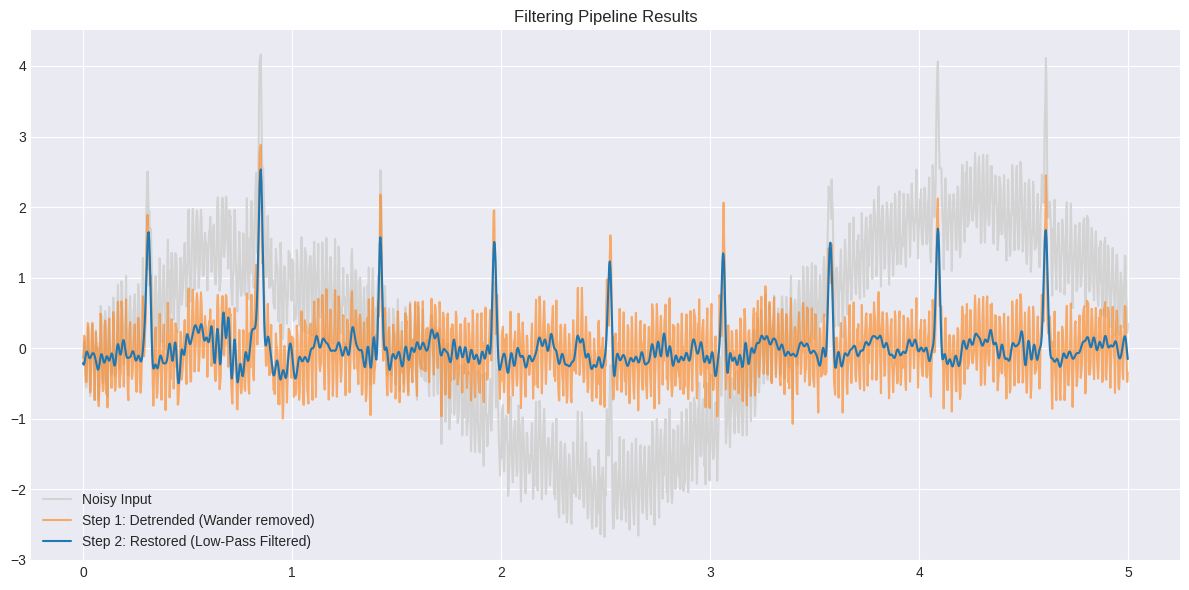

In [ ]:


drift_estimate = moving_average(noisy_ecg, window_size=180)


detrended_ecg = noisy_ecg - drift_estimate



restored_ecg = fourier_low_pass_filter(detrended_ecg, sample_rate=fs, cutoff_freq=40.0)

plt.figure(figsize=(12, 6))
plt.plot(t, noisy_ecg, color='lightgray', label='Noisy Input')
plt.plot(t, detrended_ecg, color='tab:orange', alpha=0.6, label='Step 1: Detrended (Wander removed)')
plt.plot(t, restored_ecg, color='tab:blue', linewidth=1.5, label='Step 2: Restored (Low-Pass Filtered)')
plt.title('Filtering Pipeline Results')
plt.legend()
plt.tight_layout()
plt.show()

---- Performance Repair Metrics ----
Noisy Signal RMSE: 1.128
Restored Signal RMSE: 0.369

Noisy Signal SNR: -7.09 dB
Restored Signal SNR: 2.61 dB


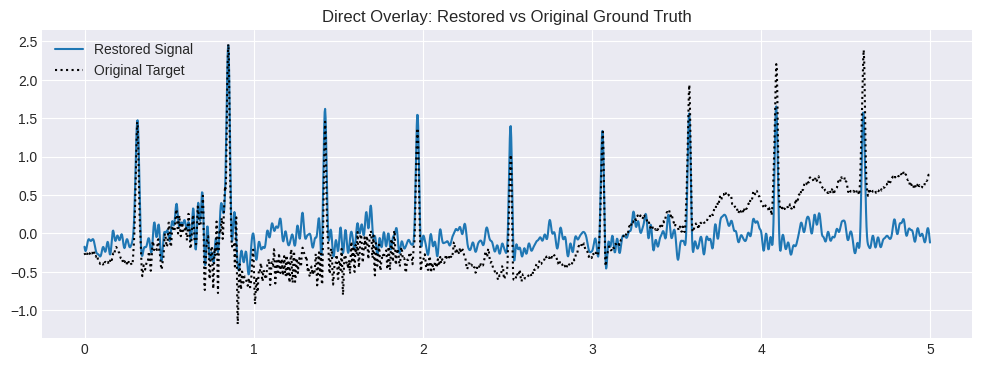

In [ ]:

from src.evaluation import calculate_rmse, calculate_snr

print("---- Performance Repair Metrics ----")
print(f"Noisy Signal RMSE: {calculate_rmse(clean_ecg, noisy_ecg):.3f}")
print(f"Restored Signal RMSE: {calculate_rmse(clean_ecg, restored_ecg):.3f}")
print(f"\nNoisy Signal SNR: {calculate_snr(clean_ecg, noisy_ecg):.2f} dB")
print(f"Restored Signal SNR: {calculate_snr(clean_ecg, restored_ecg):.2f} dB")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, restored_ecg, color='tab:blue', label='Restored Signal')
ax.plot(t, clean_ecg, color='black', linestyle=':', label='Original Target')
ax.set_title('Direct Overlay: Restored vs Original Ground Truth')
ax.legend()
plt.savefig("/home/ritwik/Pictures/Screenshots/ecg_comparison.png")
plt.show()